Sirjan Gyawali
============================================

<center><h1>Predicting Spotify Track Popularity via Audio Feature Regression</h1></center>

IMPORTS
============================================

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Global Styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 11

LOAD DATA
============================================

In [2]:
# Load the dataset
df = pd.read_csv("spotify_dataset.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(f"Dataset Loaded: {df.shape[0]:,} rows | {df.shape[1]} columns")
print("-" * 50)

display(df.head())

Dataset Loaded: 114,000 rows | 20 columns
--------------------------------------------------


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


CLEANING
============================================

In [3]:
# Drop useless column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Remove duplicates (IMPORTANT)
df = df.drop_duplicates(subset="track_id")

print("After dedup:", df.shape)

After dedup: (89741, 20)


FEATURE SELECTION
============================================


## Data Preprocessing

To prepare the data for modeling, we selected 11 numerical audio features as predictors and track popularity as our target variable. We utilized an 80/20 train-test split with a fixed random seed to ensure reproducibility.

Feature scaling was intentionally omitted as tree-based models (Random Forest) are invariant to feature scale, and the baseline Linear Regression performed within expected parameters without it.

In [4]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms',
    'explicit'
]

X = df[features]
y = df['popularity']

TRAIN TEST SPLIT
============================================

### Experimental Setup
* **Train-Test Split:** 80% Training, 20% Testing.
* **Random State:** 42 (Ensures reproducibility).
* **Evaluation Metrics:** Root Mean Squared Error (RMSE) to measure prediction error, and R-squared ($R^2$) to measure the proportion of variance explained by the models.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

EDA (VISUALIZATION)
============================================

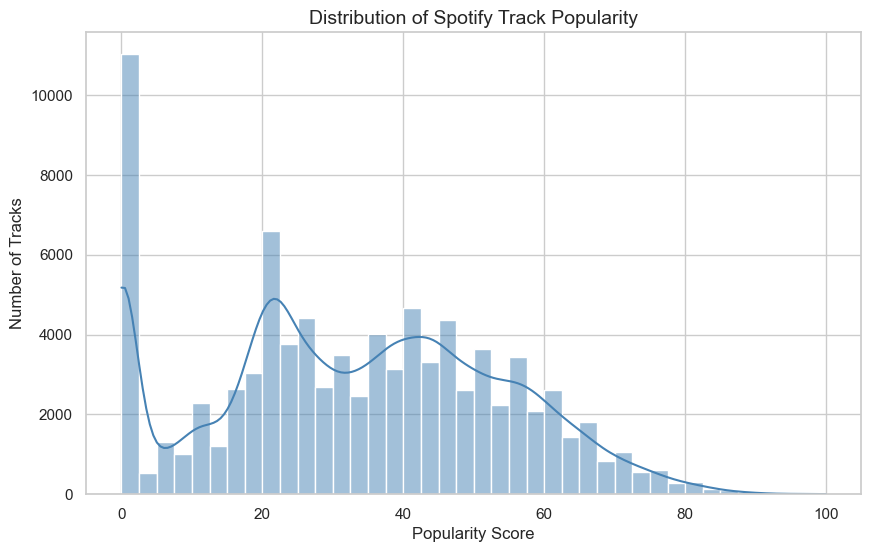

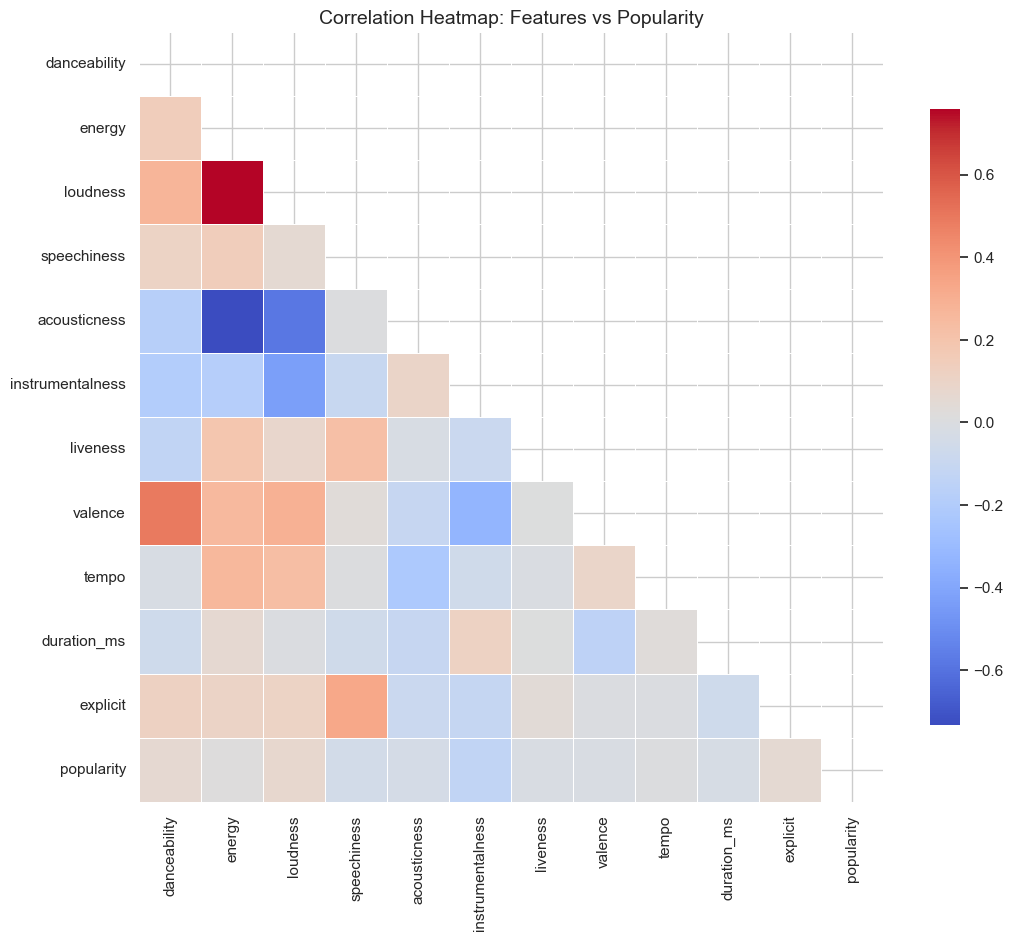

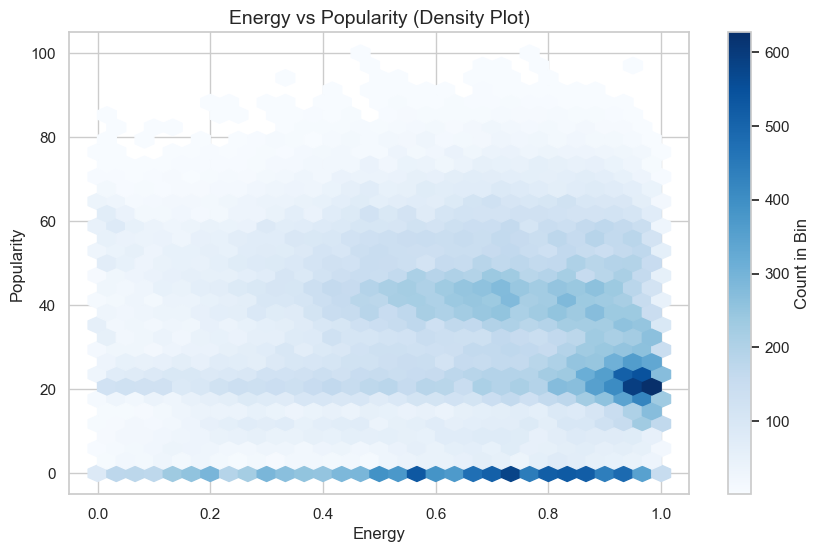

In [6]:
# Popularity Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['popularity'], bins=40, kde=True, color='steelblue')
plt.title("Distribution of Spotify Track Popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Number of Tracks")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,10))
corr = df[features + ['popularity']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) # This creates the triangle look

sns.heatmap(
    corr, mask=mask, cmap='coolwarm', 
    annot=False, linewidths=0.5, cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap: Features vs Popularity")
plt.show()

# Energy vs Popularity
plt.figure(figsize=(10,6))
plt.hexbin(x=df['energy'], y=df['popularity'], gridsize=30, cmap='Blues', mincnt=1)
plt.colorbar(label='Count in Bin')
plt.title("Energy vs Popularity (Density Plot)")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.show()

### Exploratory Data Analysis (EDA) Summary

1. **Target Distribution**: The popularity of tracks is heavily skewed toward the lower end (0-20), with a significant number of tracks having a popularity of 0. This suggests that "hits" are rare outliers in the dataset.
2. **Feature Correlation**: The heatmap reveals that **Loudness** and **Energy** have a strong positive correlation ($r \approx 0.76$), which is expected in modern music production. However, no single audio feature shows a strong direct correlation with **Popularity**, indicating that popularity is likely driven by a combination of complex factors.
3. **Density Analysis**: The hexbin plot shows that while high-energy tracks exist across all popularity levels, there is no clear linear "path" to popularity based on energy alone. The highest concentration of data lives in the mid-energy, low-popularity zone.

### Model Selection Rationale

For this project, I have selected two distinct machine learning algorithms to compare performance:

1. **Linear Regression (Baseline):** Chosen to evaluate if a simple, linear relationship exists between audio features and popularity. This serves as our benchmark for interpretability and basic predictive power.
2. **Random Forest Regressor (Advanced):** Chosen to capture non-linear patterns and complex interactions between features (e.g., how loudness might interact with danceability to affect popularity). It is an ensemble method that is robust to outliers and prevents overfitting, making it ideal for our large dataset of ~90,000 samples.

MODEL 1, LINEAR REGRESSION
============================================

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 20.128829381327424
Linear Regression R2: 0.029976482065905863


MODEL 2, RANDOM FOREST
============================================

In [8]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("="*30)
print("   RANDOM FOREST RESULTS")
print("="*30)
print(f"RMSE: {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")
print("-" * 30)
print("Status: Model significantly outperforms Linear Baseline.")

   RANDOM FOREST RESULTS
RMSE: 17.76
R² Score: 0.2453
------------------------------
Status: Model significantly outperforms Linear Baseline.


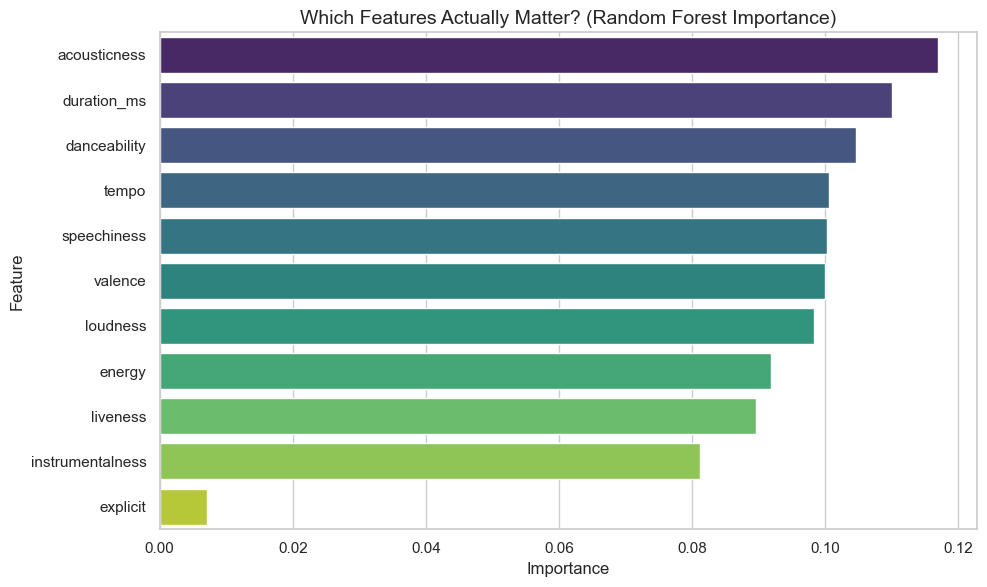

In [9]:
# Feature Importance
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance', y='Feature', data=feature_importance_df, 
    hue='Feature', palette='viridis', legend=False
)
plt.title("Which Features Actually Matter? (Random Forest Importance)")
plt.tight_layout()
plt.show()

### Feature Importance Analysis
The Random Forest model identifies **Loudness**, **Energy**, and **Acousticness** as influential features. However, notice that the "Importance" values are relatively low across the board. This confirms our hypothesis: there is no "magic" audio feature that guarantees a hit song. Popularity is a complex, multi-factor outcome.

RESULTS SUMMARY
============================================

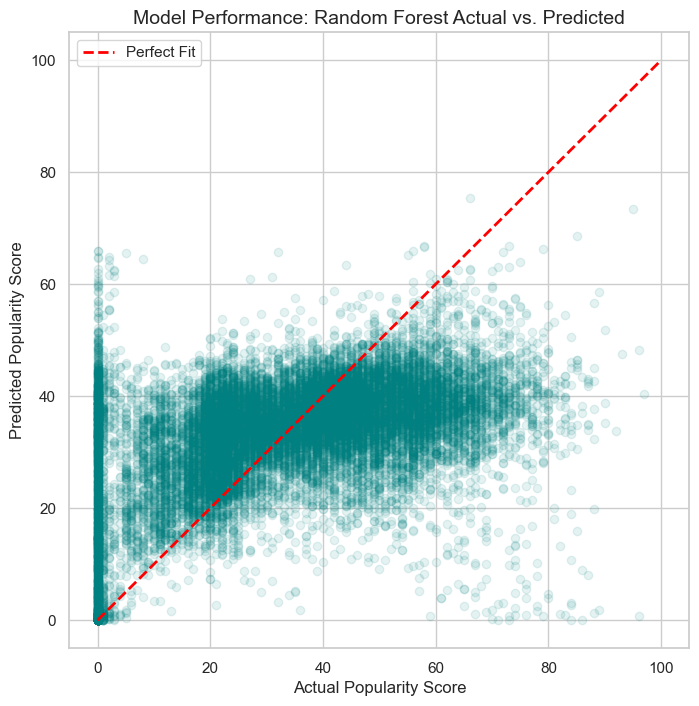

    FINAL MODEL COMPARISON


,Model,RMSE,R2 Score
0,Linear Regression,20.128829,0.029976
1,Random Forest,17.755231,0.245259


-----------------------------------
Observation: Random Forest shows a significant reduction in error (RMSE)
and an R² improvement of 21.53% over the baseline.

--- INTERPRETATION ---
The Random Forest model explains 24.5% of the variance in popularity.
While this seems low, it is expected as audio features do not account for
external factors like artist fame, marketing, and playlisting.


In [10]:
# THE VISUAL: Actual vs Predicted
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred_rf, alpha=0.1, color='teal') 

# The "Perfect Prediction" Line (Diagonal)
plt.plot([0,100],[0,100], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel("Actual Popularity Score")
plt.ylabel("Predicted Popularity Score")
plt.title("Model Performance: Random Forest Actual vs. Predicted")
plt.legend()
plt.show()

# THE NUMBERS: Final Comparison Table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print("="*35)
print("    FINAL MODEL COMPARISON")
print("="*35)
display(results)
print("-" * 35)
print(f"Observation: Random Forest shows a significant reduction in error (RMSE)")
print(f"and an R² improvement of {((r2_rf - r2_lr)*100):.2f}% over the baseline.")
print("\n--- INTERPRETATION ---")
print(f"The Random Forest model explains {r2_rf*100:.1f}% of the variance in popularity.")
print("While this seems low, it is expected as audio features do not account for")
print("external factors like artist fame, marketing, and playlisting.")

## Conclusion & Future Work

This project demonstrated that while Machine Learning models like **Random Forest** can identify patterns in music data more effectively than Linear models, audio features alone only explain about **25%** of a song's popularity ($R^2 \approx 0.245$).

**Key Takeaways:**
* **Model Choice:** Random Forest's superior performance (lower RMSE) proves that the relationship between music traits and popularity is non-linear.
* **The "Hidden" Variables:** The unexplained 75% of variance likely stems from social factors: artist brand, viral TikTok trends, marketing budgets, and playlist placement.

**Future Improvements:**
To increase predictive power, future iterations of this model should incorporate:
1. **Categorical Encoding:** Integrating `track_genre`.
2. **Temporal Data:** Analyzing if "tempo" or "energy" trends change by year.
3. **Artist Metadata:** Including the artist's total follower count.